      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


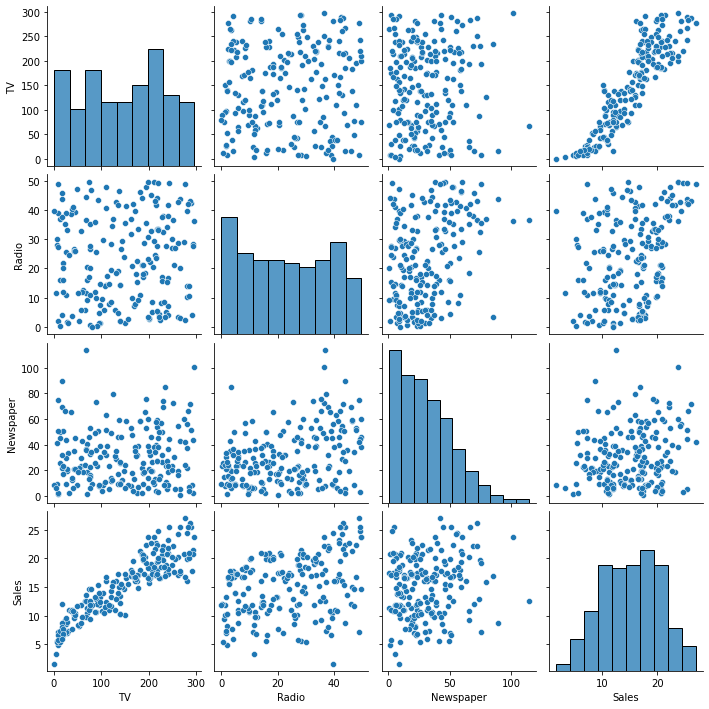

        Model       MAE       MSE      RMSE
0      Linear  1.274826  2.907757  1.705215
1  Polynomial  0.903371  1.442543  1.201059
2         SVR  1.483622  3.499087  1.870585


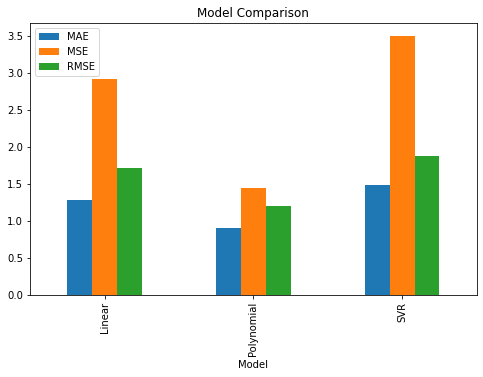

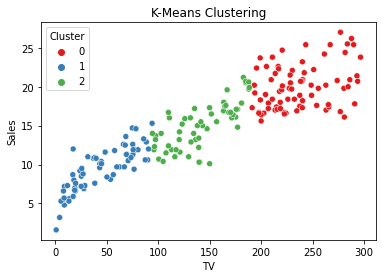

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv(r"C:\Users\HDC0422044\Downloads\archive (10)\advertising.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

sns.pairplot(df[["TV", "Radio", "Newspaper", "Sales"]])
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

pr = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
pr.fit(X_train, y_train)
pr_pred = pr.predict(X_test)

svr = SVR(kernel="rbf")
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)

models = ["Linear", "Polynomial", "SVR"]
mae = [
    mean_absolute_error(y_test, lr_pred),
    mean_absolute_error(y_test, pr_pred),
    mean_absolute_error(y_test, svr_pred)
]

mse = [
    mean_squared_error(y_test, lr_pred),
    mean_squared_error(y_test, pr_pred),
    mean_squared_error(y_test, svr_pred)
]

rmse = [np.sqrt(i) for i in mse]

result = pd.DataFrame({
    "Model": models,
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse
})

print(result)

result.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

sns.scatterplot(data=df, x="TV", y="Sales", hue="Cluster", palette="Set1")
plt.title("K-Means Clustering")
plt.show()